# 🧩 Block Diagram Visualization

This notebook renders a Jaxonomy model as a **block diagram** so you can inspect its
wiring, ports, and hierarchy before simulating. The renderer is **pure Python +
matplotlib** — no JavaScript, no CDN, no Jupyter widget extensions — so it works
identically in VS Code, JupyterLab, Classic Notebook, Claude, and `nbconvert`
pipelines.

## Model: Damped Pendulum with PD Control

We build two related diagrams:

1. **Pendulum Plant** — 9 primitive blocks implementing the equations of motion
   $$\dot{\theta} = \omega, \qquad \dot{\omega} = -\tfrac{g}{L}\sin\theta - \tfrac{b}{mL^2}\omega + \tfrac{\tau}{mL^2}$$

2. **PD-Controlled Pendulum** — closed-loop diagram wrapping the plant with a proportional-derivative feedback controller
   $$\tau = -k_p\,\theta - k_d\,\omega$$

The second diagram has an explicit **feedback loop** from the plant output back through the controller to its input.

## 🔧 Setup

The renderer uses **pure Python + matplotlib** — no JavaScript, no CDN, no
Jupyter widget extensions.  Works identically in VS Code, JupyterLab,
Classic Notebook, and `nbconvert` pipelines.

| What | Detail |
|------|--------|
| **Layout** | DFS cycle detection → BFS longest-path layering (pure Python) |
| **Rendering** | `matplotlib.patches.FancyBboxPatch` + `annotate` arrows |
| **Output** | Inline `Figure` — display in notebook or `fig.savefig()` |
| **Dependencies** | `matplotlib`, `numpy` (already required by Jaxonomy) |


In [1]:
import jax.numpy as jnp
import jaxonomy as jx
from jaxonomy import DiagramBuilder
from jaxonomy.library import (
    Integrator, Gain, Adder,
    Demultiplexer, Multiplexer, Trigonometric,
)

print("Imports OK.")


Imports OK.


---
## 📐 Build the Jaxonomy Models

### Model 1 — Pendulum Plant (9 primitives + integration feedback loop)

Implements the nonlinear pendulum ODE from first principles using `Integrator`, `Gain`, `Adder`, `Demultiplexer`, `Multiplexer`, and `Trigonometric` blocks.

```
                    ┌──────────────────────────────────────────────────────┐
              τ ──▶ │ Gain_tau ──▶ Adder_u ◀── Adder_dyn ◀─ Gain_grav ◀─ Sine_0 ◀─ θ │
                    │                  │           ▲                                    │
                    │                  │      Gain_damp ◀──── ω                         │
                    │                  ▼                                                │
                    │  [θ,ω] ◀── Integrator_0 ◀── Mux_0 ◀── Demux_0 ──▶ (θ, ω)       │
                    └──────────────────────────────────────────────────────┘
```

In [2]:
def make_pendulum(x0=[1.0, 0.0], m=1.0, g=9.81, L=1.0, b=0.5, name="pendulum"):
    """
    Pendulum plant built from primitive blocks.

    Equations of motion:
        θ̇ = ω
        ω̇ = -(g/L)·sin(θ) - (b/mL²)·ω + τ/(mL²)

    Exported input  port 0: τ  (external torque)
    Exported output port 0: [θ, ω]  (full state)
    """
    builder = DiagramBuilder()

    # ── State integration ────────────────────────────────────────────
    integrator = builder.add(Integrator(x0, name="Integrator_0"))
    demux      = builder.add(Demultiplexer(2, name="Demux_0"))
    builder.connect(integrator.output_ports[0], demux.input_ports[0])

    # ── Gravity term: -g/L · sin(θ) ──────────────────────────────────
    sine    = builder.add(Trigonometric("sin", name="Sine_0"))
    gain_g  = builder.add(Gain(-g / L, name="Gain_grav"))
    builder.connect(demux.output_ports[0], sine.input_ports[0])
    builder.connect(sine.output_ports[0], gain_g.input_ports[0])

    # ── Damping term: -b/(mL²) · ω ───────────────────────────────────
    gain_d = builder.add(Gain(-b / (m * L**2), name="Gain_damp"))
    builder.connect(demux.output_ports[1], gain_d.input_ports[0])

    # ── Sum dynamics ──────────────────────────────────────────────────
    adder_dyn = builder.add(Adder(2, name="Adder_dyn"))
    builder.connect(gain_g.output_ports[0], adder_dyn.input_ports[0])
    builder.connect(gain_d.output_ports[0], adder_dyn.input_ports[1])

    # ── Torque input: τ/(mL²) ─────────────────────────────────────────
    gain_tau = builder.add(Gain(1.0 / (m * L**2), name="Gain_tau"))
    adder_u  = builder.add(Adder(2, name="Adder_u"))
    builder.connect(adder_dyn.output_ports[0], adder_u.input_ports[0])
    builder.connect(gain_tau.output_ports[0], adder_u.input_ports[1])

    # ── Multiplexer + feedback to integrator ─────────────────────────
    mux = builder.add(Multiplexer(2, name="Mux_0"))
    builder.connect(demux.output_ports[1], mux.input_ports[0])   # ω pass-through
    builder.connect(adder_u.output_ports[0], mux.input_ports[1])
    builder.connect(mux.output_ports[0], integrator.input_ports[0])  # ← FEEDBACK

    builder.export_input(gain_tau.input_ports[0])
    builder.export_output(integrator.output_ports[0])

    return builder.build(name=name)


pendulum_plant = make_pendulum()
print("Pendulum plant:")
pendulum_plant.pprint()

Pendulum plant:
│── pendulum <Diagram>
    │── Integrator_0 <Integrator> [out_0 → Demux_0.in_0]
    │── Demux_0 <Demultiplexer> [out_0 → Sine_0.in_0, out_1 → Gain_damp.in_0, out_1 → Mux_0.in_0]
    │── Sine_0 <Trigonometric> [out_0 → Gain_grav.in_0]
    │── Gain_grav <Gain> [out_0 → Adder_dyn.in_0]
    │── Gain_damp <Gain> [out_0 → Adder_dyn.in_1]
    │── Adder_dyn <Adder> [out_0 → Adder_u.in_0]
    │── Gain_tau <Gain> [out_0 → Adder_u.in_1]
    │── Adder_u <Adder> [out_0 → Mux_0.in_1]
    │── Mux_0 <Multiplexer> [out_0 → Integrator_0.in_0]


### Model 2 — PD-Controlled Pendulum (5 top-level blocks + closed feedback loop)

Wraps the pendulum plant with a proportional-derivative controller. The critical feedback path is:

$$
\underbrace{\text{pendulum}}_\text{plant} \;\xrightarrow{[\theta,\omega]}\;
\text{Demux} \;\xrightarrow{\theta,\,\omega}\;
\text{Gains} \;\xrightarrow{}\;
\text{Adder} \;\xrightarrow{\tau}\;
\underbrace{\text{pendulum}}_\text{plant}
$$

In [3]:
def make_pd_pendulum(kp=10.0, kd=2.0, name="pd_pendulum"):
    """
    PD-controlled pendulum.  The pendulum sub-diagram is treated as a single
    black box here — its internal 9-block structure is invisible at this level.
    """
    pendulum = make_pendulum(b=0.3)
    builder  = DiagramBuilder()
    builder.add(pendulum)

    demux   = builder.add(Demultiplexer(2, name="Demux_ctrl"))
    gain_p  = builder.add(Gain(-kp,  name="Gain_kp"))
    gain_d  = builder.add(Gain(-kd,  name="Gain_kd"))
    adder   = builder.add(Adder(2,   name="Adder_ctrl"))

    # State feedback: plant output → controller
    builder.connect(pendulum.output_ports[0], demux.input_ports[0])
    builder.connect(demux.output_ports[0],    gain_p.input_ports[0])  # θ → -kp·θ
    builder.connect(demux.output_ports[1],    gain_d.input_ports[0])  # ω → -kd·ω
    builder.connect(gain_p.output_ports[0],   adder.input_ports[0])
    builder.connect(gain_d.output_ports[0],   adder.input_ports[1])

    # Control action fed back to plant  ← THE FEEDBACK LOOP
    builder.connect(adder.output_ports[0], pendulum.input_ports[0])

    return builder.build(name=name)


pd_diagram = make_pd_pendulum()
print("PD-controlled pendulum:")
pd_diagram.pprint()

PD-controlled pendulum:
│── pd_pendulum <Diagram>
    │── pendulum <Diagram> [Integrator_0_out_0 → Demux_ctrl.in_0]
        │── Integrator_0 <Integrator> [out_0 → Demux_0.in_0]
        │── Demux_0 <Demultiplexer> [out_0 → Sine_0.in_0, out_1 → Gain_damp.in_0, out_1 → Mux_0.in_0]
        │── Sine_0 <Trigonometric> [out_0 → Gain_grav.in_0]
        │── Gain_grav <Gain> [out_0 → Adder_dyn.in_0]
        │── Gain_damp <Gain> [out_0 → Adder_dyn.in_1]
        │── Adder_dyn <Adder> [out_0 → Adder_u.in_0]
        │── Gain_tau <Gain> [out_0 → Adder_u.in_1]
        │── Adder_u <Adder> [out_0 → Mux_0.in_1]
        │── Mux_0 <Multiplexer> [out_0 → Integrator_0.in_0]
    │── Demux_ctrl <Demultiplexer> [out_0 → Gain_kp.in_0, out_1 → Gain_kd.in_0]
    │── Gain_kp <Gain> [out_0 → Adder_ctrl.in_0]
    │── Gain_kd <Gain> [out_0 → Adder_ctrl.in_1]
    │── Adder_ctrl <Adder> [out_0 → pendulum.Gain_tau_in_0]


---
## 🔍 Graph Extraction

Jaxonomy exposes the diagram structure via two attributes:

- `diagram.nodes` — list of child subsystems at this level
- `diagram.connection_map` — `dict[InputPortLocator, OutputPortLocator]` where each locator is `(SystemBase, port_index)`

The helper below converts these into plain Python dicts that the visualization libraries can consume.

In [4]:
def extract_graph(diagram):
    """
    Walk diagram.nodes and diagram.connection_map to produce
    two plain lists: blocks and connections.

    Returns
    -------
    blocks : list of dict
        {id, name, type, n_inputs, n_outputs}
    connections : list of dict
        {src, src_port, dst, dst_port}  — src/dst are block names (str)
    """
    blocks = []
    for node in diagram.nodes:
        blocks.append({
            "id":       node.name,
            "name":     node.name,
            "type":     type(node).__name__,
            "n_inputs":  len(node.input_ports),
            "n_outputs": len(node.output_ports),
        })

    connections = []
    for (dst_sys, dst_port_idx), (src_sys, src_port_idx) in diagram.connection_map.items():
        connections.append({
            "src":      src_sys.name,
            "src_port": src_port_idx,
            "dst":      dst_sys.name,
            "dst_port": dst_port_idx,
        })

    return blocks, connections


# ── Inspect both diagrams ────────────────────────────────────────────────────
for diag in [pendulum_plant, pd_diagram]:
    blocks, connections = extract_graph(diag)
    print(f"\n{'─'*55}")
    print(f" Diagram: {diag.name}")
    print(f"{'─'*55}")
    print(f" {'Block':<20} {'Type':<18} {'In':>3} {'Out':>4}")
    print(f" {'─'*18:<20} {'─'*16:<18} {'─'*3:>3} {'─'*4:>4}")
    for b in blocks:
        print(f" {b['name']:<20} {b['type']:<18} {b['n_inputs']:>3} {b['n_outputs']:>4}")
    print(f"\n Connections ({len(connections)}):")
    for c in connections:
        print(f"   {c['src']}.out[{c['src_port']}]  →  {c['dst']}.in[{c['dst_port']}]")


───────────────────────────────────────────────────────
 Diagram: pendulum
───────────────────────────────────────────────────────
 Block                Type                In  Out
 ──────────────────   ────────────────   ─── ────
 Integrator_0         Integrator           1    1
 Demux_0              Demultiplexer        1    2
 Sine_0               Trigonometric        1    1
 Gain_grav            Gain                 1    1
 Gain_damp            Gain                 1    1
 Adder_dyn            Adder                2    1
 Gain_tau             Gain                 1    1
 Adder_u              Adder                2    1
 Mux_0                Multiplexer          2    1

 Connections (11):
   Integrator_0.out[0]  →  Demux_0.in[0]
   Demux_0.out[0]  →  Sine_0.in[0]
   Sine_0.out[0]  →  Gain_grav.in[0]
   Demux_0.out[1]  →  Gain_damp.in[0]
   Gain_grav.out[0]  →  Adder_dyn.in[0]
   Gain_damp.out[0]  →  Adder_dyn.in[1]
   Adder_dyn.out[0]  →  Adder_u.in[0]
   Gain_tau.out[0]  →  Adder_

---
## 📊 Block Diagram Renderer

The renderer below is **100 % Python + matplotlib** — no JavaScript, no CDN, no
Jupyter widgets.  It works in VS Code, JupyterLab, Classic Notebook, and CI
pipelines that call `nbconvert`.

### How it works

1. `extract_graph(diagram)` reads `diagram.nodes` and `diagram.connection_map`
   to produce a flat list of *blocks* and *connections*.
2. `_assign_layers()` does a **DFS-based cycle detection** (marks feedback
   edges), then a **BFS longest-path layering** on the resulting DAG so every
   forward edge spans at least one layer.
3. `render_diagram()` draws each block as a colour-coded rounded rectangle
   and routes forward edges as smooth curved arrows; feedback/back-edges use the same grey arrow, routed around the bottom.


In [5]:
from collections import defaultdict, deque
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import numpy as np

# ── colour palette (fill, stroke) ────────────────────────────────────────────
_COLORS = {
    "Integrator":    ("#dbeafe", "#3b82f6"),
    "Gain":          ("#dcfce7", "#22c55e"),
    "Adder":         ("#fef3c7", "#f59e0b"),
    "Demultiplexer": ("#f3e8ff", "#a855f7"),
    "Multiplexer":   ("#ede9fe", "#8b5cf6"),
    "Trigonometric": ("#fce7f3", "#ec4899"),
    "Diagram":       ("#e0f2fe", "#0ea5e9"),
    "LTISystem":     ("#dcfce7", "#16a34a"),
    "Constant":      ("#f1f5f9", "#94a3b8"),
}
_DEFAULT_CLR = ("#f1f5f9", "#94a3b8")


def _hex(h):
    h = h.lstrip("#")
    return tuple(int(h[i:i+2], 16) / 255 for i in (0, 2, 4))


def _assign_layers(blocks, connections):
    """
    Return (layer_map, back_edge_set).

    * layer_map   : {block_id -> int}
    * back_edge_set: set of (src_id, dst_id) tuples that are feedback edges
    """
    ids = [b["id"] for b in blocks]
    idx = {bid: i for i, bid in enumerate(ids)}
    n = len(ids)

    # Collect unique directed edges (ignore self-loops / external nodes)
    all_edges = set()
    for c in connections:
        s, d = idx.get(c["src"], -1), idx.get(c["dst"], -1)
        if s >= 0 and d >= 0 and s != d:
            all_edges.add((s, d))

    # --- DFS to label back edges -----------------------------------------
    color = [0] * n   # 0 = white, 1 = grey (in stack), 2 = black (done)
    back_idx = set()  # (s, d) index pairs

    def dfs(u):
        color[u] = 1
        for (s, d) in all_edges:
            if s != u:
                continue
            if color[d] == 1:
                back_idx.add((u, d))
            elif color[d] == 0:
                dfs(d)
        color[u] = 2

    for i in range(n):
        if color[i] == 0:
            dfs(i)

    # --- BFS longest-path layering on DAG --------------------------------
    fwd_adj  = defaultdict(list)   # src -> [dst]
    in_deg   = [0] * n
    for (s, d) in all_edges:
        if (s, d) not in back_idx:
            fwd_adj[s].append(d)
            in_deg[d] += 1

    layer = [0] * n
    q = deque(i for i in range(n) if in_deg[i] == 0)
    in_deg_copy = in_deg[:]

    while q:
        u = q.popleft()
        for v in fwd_adj[u]:
            layer[v] = max(layer[v], layer[u] + 1)
            in_deg_copy[v] -= 1
            if in_deg_copy[v] == 0:
                q.append(v)

    layer_map = {ids[i]: layer[i] for i in range(n)}
    back_edges = {(ids[s], ids[d]) for (s, d) in back_idx}
    return layer_map, back_edges


def render_diagram(diagram, title="Diagram", figsize=(14, 5)):
    """
    Render a Jaxonomy Diagram as a matplotlib block diagram.

    Parameters
    ----------
    diagram : jaxonomy Diagram
    title   : str
    figsize : tuple

    Returns
    -------
    matplotlib.figure.Figure
        Display with ``fig`` as the last expression in a cell, or call
        ``fig.savefig('out.svg')`` to save.
    """
    blocks, connections = extract_graph(diagram)
    if not blocks:
        fig, ax = plt.subplots(figsize=(4, 2))
        ax.text(0.5, 0.5, "Empty diagram", ha="center", va="center",
                transform=ax.transAxes, fontsize=12, color="#94a3b8")
        ax.axis("off")
        return fig

    layer_map, back_edges = _assign_layers(blocks, connections)

    # Group blocks by layer, sort layers
    by_layer = defaultdict(list)
    for b in blocks:
        by_layer[layer_map[b["id"]]].append(b)
    n_layers = max(layer_map.values()) + 1

    # --- Block geometry ---------------------------------------------------
    BW, BH    = 1.9, 0.75    # block width / height
    H_GAP     = 3.2          # centre-to-centre horizontal spacing
    V_GAP     = 1.3          # centre-to-centre vertical spacing
    max_rows  = max(len(v) for v in by_layer.values())

    # Assign centre positions
    pos = {}   # block_id -> (cx, cy)
    for li in range(n_layers):
        blist = by_layer[li]
        cx = li * H_GAP
        col_h = (len(blist) - 1) * V_GAP
        for ri, b in enumerate(blist):
            cy = col_h / 2 - ri * V_GAP
            pos[b["id"]] = (cx, cy)

    # --- Figure setup -----------------------------------------------------
    margin_x, margin_y = 1.2, 0.8
    w = (n_layers - 1) * H_GAP + BW + 2 * margin_x
    h = (max_rows - 1) * V_GAP + BH + 2 * margin_y
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-BW / 2 - margin_x, (n_layers - 1) * H_GAP + BW / 2 + margin_x)
    ax.set_ylim(-h / 2, h / 2)
    ax.set_aspect("equal")
    ax.axis("off")
    fig.patch.set_facecolor("#f8fafc")
    ax.set_facecolor("#f8fafc")

    # --- Draw edges -------------------------------------------------------
    for c in connections:
        sid, did = c["src"], c["dst"]
        if sid not in pos or did not in pos:
            continue
        sx, sy = pos[sid]
        dx, dy = pos[did]
        is_back = (sid, did) in back_edges

        if is_back:
            # A feedback edge is still an ordinary signal link, so it uses the
            # same grey solid arrow (with arrowhead) as the forward edges — it is
            # just routed gently BELOW the row so the loop reads clockwise.
            ax.annotate(
                "", xy=(dx, dy - BH / 2), xytext=(sx, sy - BH / 2),
                arrowprops=dict(
                    arrowstyle="-|>",
                    mutation_scale=20,
                    color="#94a3b8",
                    lw=1.4,
                    connectionstyle="arc3,rad=-0.35",
                    shrinkA=2, shrinkB=2,
                ),
                zorder=1,
            )
        else:
            rad = 0.0 if abs(sy - dy) < 0.05 else (0.18 if sy > dy else -0.18)
            ax.annotate(
                "", xy=(dx - BW / 2, dy), xytext=(sx + BW / 2, sy),
                arrowprops=dict(
                    arrowstyle="-|>",
                    mutation_scale=18,
                    color="#94a3b8",
                    lw=1.4,
                    connectionstyle=f"arc3,rad={rad}",
                ),
                zorder=1,
            )

    # --- Draw blocks ------------------------------------------------------
    for b in blocks:
        if b["id"] not in pos:
            continue
        cx, cy = pos[b["id"]]
        fc_hex, ec_hex = _COLORS.get(b["type"], _DEFAULT_CLR)
        fc, ec = _hex(fc_hex), _hex(ec_hex)

        rect = mpatches.FancyBboxPatch(
            (cx - BW / 2, cy - BH / 2), BW, BH,
            boxstyle="round,pad=0.07",
            facecolor=fc, edgecolor=ec, linewidth=1.8,
            zorder=3,
        )
        ax.add_patch(rect)

        # Port indicators (small coloured circles on left/right edges)
        for pi in range(b["n_inputs"]):
            py = cy + (BH / 2) * (1 - (2 * pi + 1) / max(b["n_inputs"] * 1.2, 1))
            ax.plot(cx - BW / 2, py, "o",
                    ms=4, color=ec, mec="white", mew=1, zorder=5)
        for po in range(b["n_outputs"]):
            py = cy + (BH / 2) * (1 - (2 * po + 1) / max(b["n_outputs"] * 1.2, 1))
            ax.plot(cx + BW / 2, py, "o",
                    ms=4, color=ec, mec="white", mew=1, zorder=5)

        # Labels
        name_y  = cy + 0.11 if b["type"] else cy
        ax.text(cx, name_y, b["name"],
                ha="center", va="center", fontsize=6.5, fontweight="bold",
                color="#1e293b", zorder=4)
        if b["type"]:
            ax.text(cx, cy - 0.15, b["type"],
                    ha="center", va="center", fontsize=5.5,
                    color="#64748b", zorder=4)

    ax.set_title(title, fontsize=10, fontweight="bold",
                 pad=8, color="#1e293b")
    plt.tight_layout(pad=0.5)
    return fig


print("render_diagram() ready — pure matplotlib, no CDN or widgets.")


render_diagram() ready — pure matplotlib, no CDN or widgets.


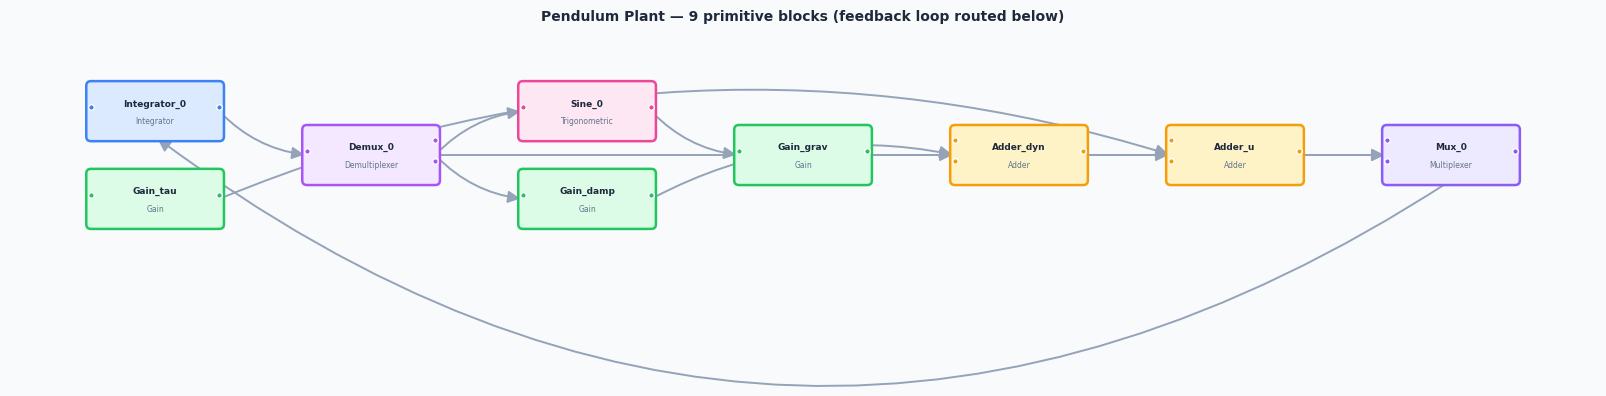

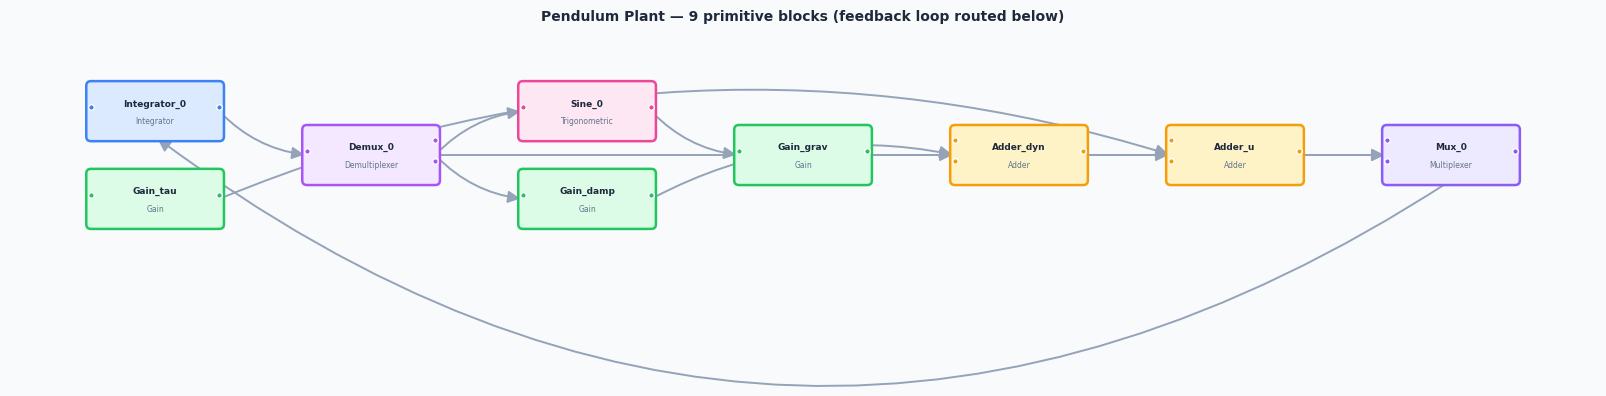

In [6]:
# ── Diagram A: Pendulum Plant (9 primitives + integration feedback loop) ─────
fig = render_diagram(
    pendulum_plant,
    title="Pendulum Plant — 9 primitive blocks (feedback loop routed below)",
    figsize=(16, 5),
)
fig


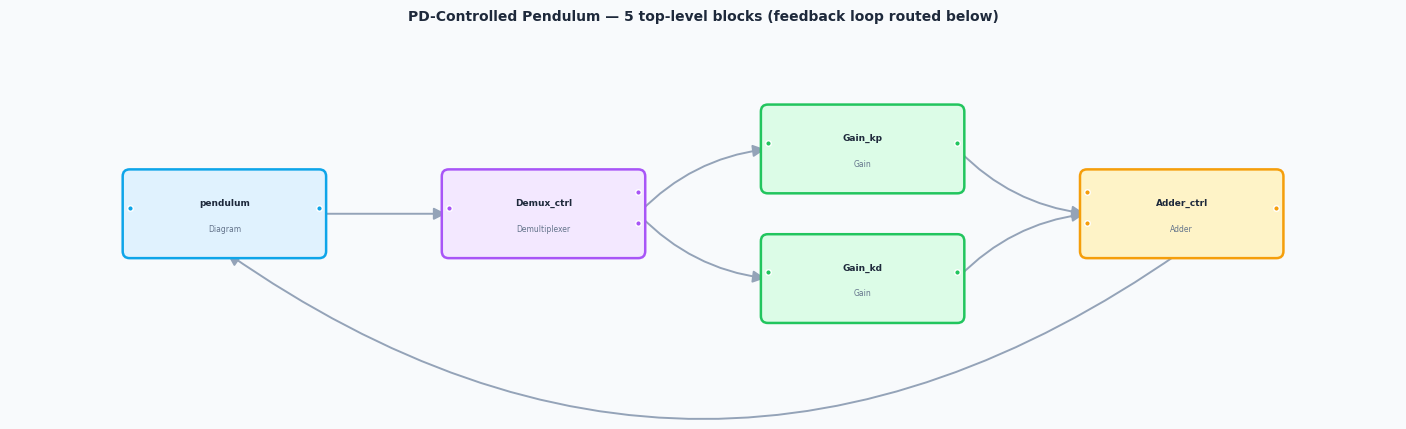

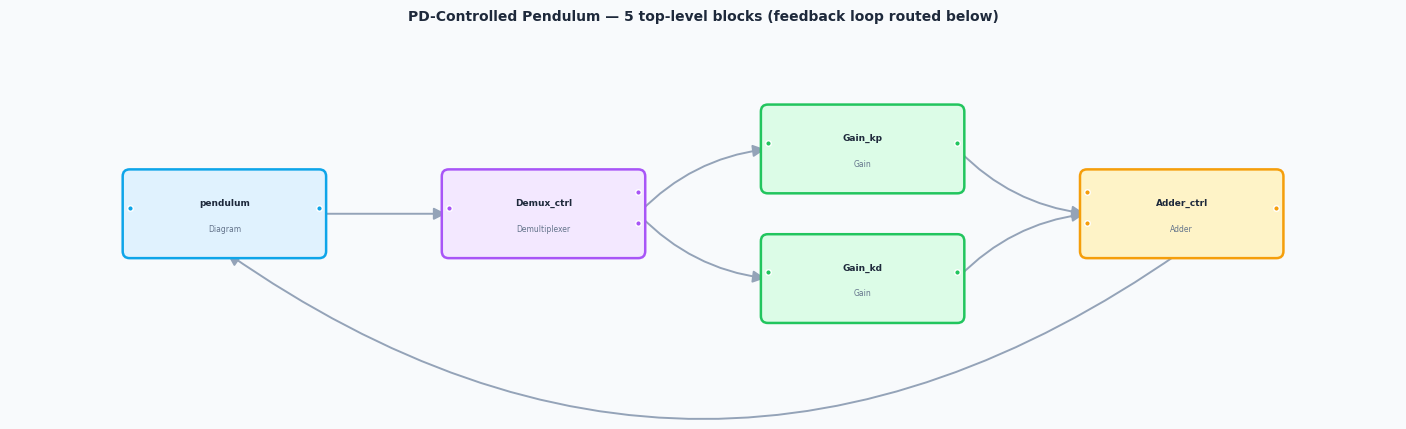

In [7]:
# ── Diagram B: PD-Controlled Pendulum (5 top-level blocks, closed loop) ──────
fig = render_diagram(
    pd_diagram,
    title="PD-Controlled Pendulum — 5 top-level blocks (feedback loop routed below)",
    figsize=(14, 5),
)
fig


---
## 🔧 Using `render_diagram` with Any Jaxonomy Diagram

```python
import jaxonomy as jx
from jaxonomy import DiagramBuilder
# … build your model …
diagram = builder.build(name="my_model")

fig = render_diagram(diagram, title="My Model", figsize=(14, 6))
fig.savefig("my_model.svg")   # or .png / .pdf
```

**Colour coding** (matches the palette above):

| Colour | Block type |
|--------|------------|
| 🔵 Blue | `Integrator` |
| 🟢 Green | `Gain` |
| 🟡 Amber | `Adder` |
| 🟣 Violet | `Demultiplexer` |
| 🔴 Pink | `Trigonometric` |
| ⚫ Grey | everything else |

Feedback edges (back-edges in the DAG) are routed as grey arrows around the bottom so the
signal-flow direction is always clear even in diagrams with multiple feedback
loops.
